## PRRE Exploratory Data Analysis & Cleaning

### The EDA Roadmap: Step-by-Step Execution

#### Step 1. Data Integration & Master Table Creation

In [1]:
import pandas as pd
import os

# 1. Define the base path
path = r'C:\Users\atifn\Downloads\Patient Re-Adm Risk Data\\'

# 2. Load the Fact Table (The Anchor)
df_master = pd.read_excel(path + 'Fact_Encounters.xlsx')

# 3. Load Dimensions
df_patients = pd.read_excel(path + 'Dim_Patients.xlsx')
df_diag = pd.read_excel(path + 'Dim_Diagnosis.xlsx')
df_hosp = pd.read_excel(path + 'Dim_Hospitals.xlsx')
df_pay = pd.read_excel(path + 'Dim_Payers.xlsx')
df_prov = pd.read_excel(path + 'Dim_Providers.xlsx')
df_date = pd.read_excel(path + 'Dim_Date.xlsx')

# 4. Perform the Joins
df_master = df_master.merge(df_patients, left_on='Patient_FK', right_on='Patient_SK', how='left')
df_master = df_master.merge(df_diag, left_on='Diagnosis_FK', right_on='Diagnosis_SK', how='left')
df_master = df_master.merge(df_hosp, left_on='Hospital_FK', right_on='Hospital_SK', how='left')
df_master = df_master.merge(df_pay, left_on='Payer_FK', right_on='Payer_SK', how='left')
df_master = df_master.merge(df_prov, left_on='Provider_FK', right_on='Provider_SK', how='left')

# 5. Role-Playing Date Joins
df_master = df_master.merge(df_date, left_on='Admission_Date_FK', right_on='Date_SK', how='left', suffixes=('', '_Admit'))
df_master = df_master.merge(df_date, left_on='Discharge_Date_FK', right_on='Date_SK', how='left', suffixes=('_Admit', '_Discharge'))

# 6. Cleanup: Remove redundant SK columns EXCEPT for Encounter_SK
# This ensures we keep the unique ID needed for Step 3
sk_columns_to_drop = [col for col in df_master.columns if col.endswith('_SK') and col != 'Encounter_SK']
df_master.drop(columns=sk_columns_to_drop, inplace=True)

# 7. Final Formatting: Round all Decimals to 2 places
df_master = df_master.round(2)

# 8. Final Check & Export
print(f"Master Table Created! Shape: {df_master.shape}")
print(f"Encounter_SK present: {'Encounter_SK' in df_master.columns}")

df_master.to_excel(path + 'Master_EDA_Phase1.xlsx', index=False)
print(f"\nFile saved as Master_EDA_Phase1.xlsx in {path}")

Master Table Created! Shape: (100000, 60)
Encounter_SK present: True

File saved as Master_EDA_Phase1.xlsx in C:\Users\atifn\Downloads\Patient Re-Adm Risk Data\\


#### Step 2: Data Quality Scrubbing

In [2]:
import pandas as pd

# 1. Define the base path
path = r'C:\Users\atifn\Downloads\Patient Re-Adm Risk Data\\'

# 2. Load the Master Table and the Quality Dimension
df_master = pd.read_excel(path + 'Master_EDA_Phase1.xlsx')
df_quality = pd.read_excel(path + 'Dim_Quality_Flags.xlsx')

# 3. Join the Quality Flags to the Master Table
df_scrubbed = df_master.merge(df_quality, left_on='Quality_Flag_FK', right_on='Quality_Flag_SK', how='left')

# 4. Perform Data Scrubbing based on available columns
# Records were retained only if they had complete vitals and no lab outliers
initial_count = len(df_scrubbed)

# Logic: Keep only rows where critical error flags are 0
df_clean = df_scrubbed[
    (df_scrubbed['is_vitals_missing'] == 0) & 
    (df_scrubbed['is_lab_outlier'] == 0)
].copy()

removed_count = initial_count - len(df_clean)

# 5. Remove Metadata and Join Keys
# Quality_Flag_SK and Quality_Flag_FK were removed
# Clinical flags (is_high_risk_flag, is_transfer, etc.) were kept as they are useful for EDA
cols_to_drop = ['Quality_Flag_SK', 'Quality_Flag_FK']
df_clean.drop(columns=cols_to_drop, inplace=True)

# 6. Final Audit and Export
print(f"Scrubbing Complete.")
print(f"Initial Records: {initial_count}")
print(f"Records Removed (Missing Vitals/Lab Outliers): {removed_count}")
print(f"Final Clean Records for EDA: {len(df_clean)}")

df_clean.to_excel(path + 'Master_EDA_Phase2.xlsx', index=False)
print(f"\nFile saved as Master_EDA_Phase2.xlsx in {path}")

Scrubbing Complete.
Initial Records: 100000
Records Removed (Missing Vitals/Lab Outliers): 10901
Final Clean Records for EDA: 89099

File saved as Master_EDA_Phase2.xlsx in C:\Users\atifn\Downloads\Patient Re-Adm Risk Data\\


#### Step 3. Feature Engineering (The Clinical Intensity Layer)

In [3]:
import pandas as pd
import os

# 1. Define the base path
path = r'C:\Users\atifn\Downloads\Patient Re-Adm Risk Data\\'

# 2. Load the required tables
df_master = pd.read_excel(path + 'Master_EDA_Phase2.xlsx')
df_bridge = pd.read_excel(path + 'Bridge_Procedures.xlsx') 
df_proc_dim = pd.read_excel(path + 'Dim_Procedures.xlsx')

# 3. Normalize column names to prevent KeyErrors
df_proc_dim.columns = df_proc_dim.columns.str.strip()
df_bridge.columns = df_bridge.columns.str.strip()
df_master.columns = df_master.columns.str.strip()

# 4. Identify the correct Cost column in Dim_Procedures
potential_cost_cols = [c for c in df_proc_dim.columns if 'Cost' in c or 'Price' in c or 'Charge' in c]
cost_col = potential_cost_cols[0] if potential_cost_cols else None

if not cost_col:
    print("Error: No cost-related column found in Dim_Procedures.")
else:
    # 5. Join Bridge with Procedure Dimension
    df_proc_combined = df_bridge.merge(df_proc_dim, left_on='Procedure_FK', right_on='Procedure_SK', how='left')

    # 6. Aggregate features at the Encounter level
    df_proc_features = df_proc_combined.groupby('Encounter_FK').agg(
        Total_Procedure_Count=('Procedure_FK', 'count'),
        Total_Procedure_Cost=(cost_col, 'sum')
    ).reset_index()

    # 7. Merge features into the Master Table
    df_final_master = df_master.merge(df_proc_features, left_on='Encounter_SK', right_on='Encounter_FK', how='left')

    # 8. Handle Nulls for non-procedural encounters
    df_final_master['Total_Procedure_Count'] = df_final_master['Total_Procedure_Count'].fillna(0).astype(int)
    df_final_master['Total_Procedure_Cost'] = df_final_master['Total_Procedure_Cost'].fillna(0.00).round(2)

    # 9. NEW FEATURE: Is_Triage_Only
    # Identifying the 10,195 encounters with zero financial footprint
    df_final_master['Is_Triage_Only'] = (df_final_master['Total_Charge'] == 0).astype(int)

    # 10. Cleanup
    if 'Encounter_FK' in df_final_master.columns:
        df_final_master.drop(columns=['Encounter_FK'], inplace=True)

    # 11. Final Audit and Export
    triage_count = df_final_master['Is_Triage_Only'].sum()
    print(f"Feature Engineering Complete.")
    print(f"Total Records: {len(df_final_master)}")
    print(f"Triage-Only Records Identified: {triage_count}")
    print(f"New Features: Total_Procedure_Count, Total_Procedure_Cost, Is_Triage_Only")

    df_final_master.to_excel(path + 'Master_EDA_Phase3.xlsx', index=False)
    print(f"\nFile saved as Master_EDA_Phase3.xlsx in {path}")

Feature Engineering Complete.
Total Records: 89099
Triage-Only Records Identified: 9060
New Features: Total_Procedure_Count, Total_Procedure_Cost, Is_Triage_Only

File saved as Master_EDA_Phase3.xlsx in C:\Users\atifn\Downloads\Patient Re-Adm Risk Data\\


#### Step 4 Univariate & Bivariate Analysis

C:\Users\atifn\AppData\Local\Temp\ipykernel_18756\723552092.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=triage_col, y=readmit_col, data=df, palette='Set2')
C:\Users\atifn\AppData\Local\Temp\ipykernel_18756\723552092.py:38: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=acuity_col, y=readmit_col, data=df, palette='viridis')


Step 4 Analysis Complete.
Verified Column Mapping: Age_at_Encounter, Readmission_30D, Acuity_Score, Is_Triage_Only
Five visualization files have been saved to the directory, including the new Triage analysis.


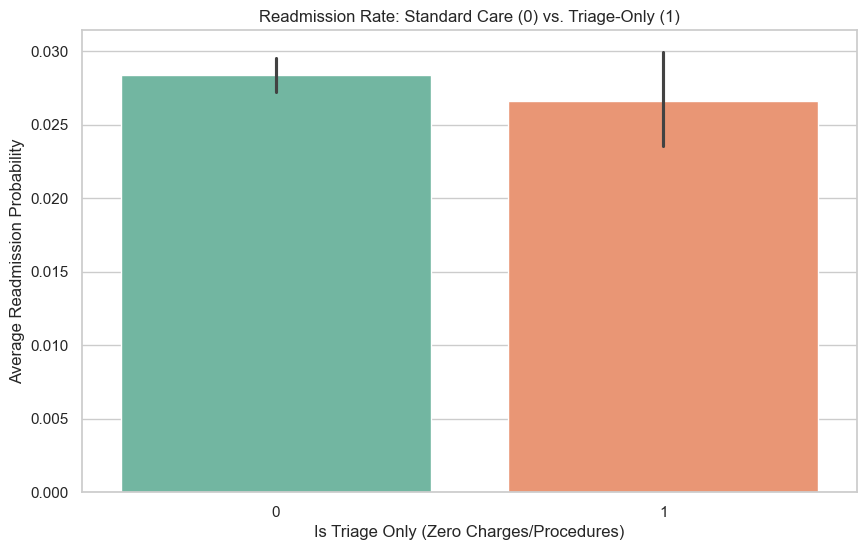

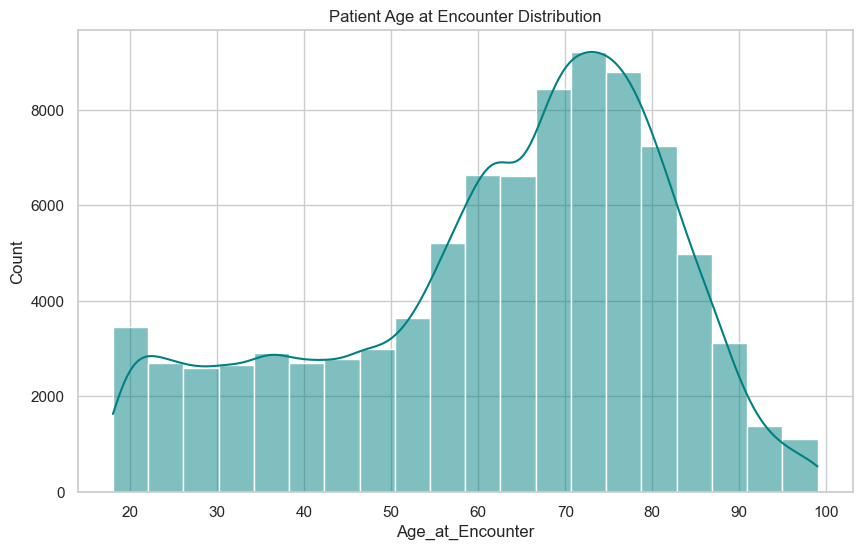

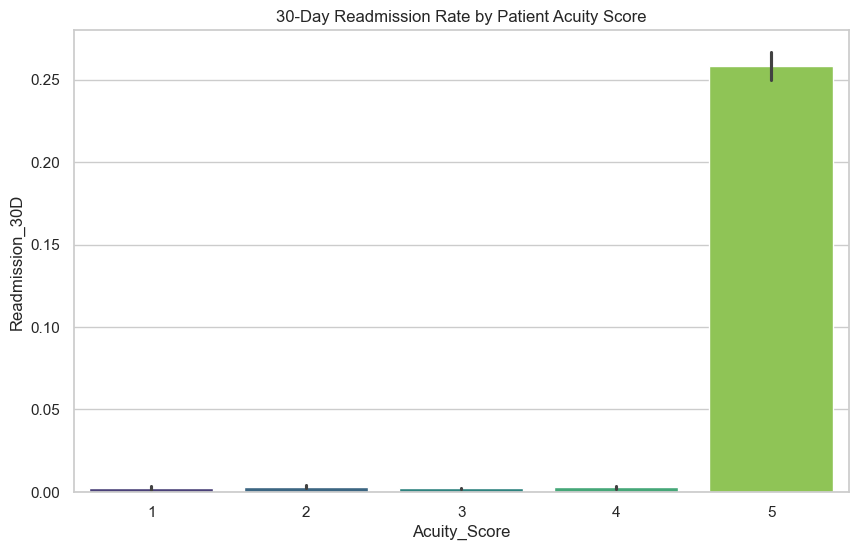

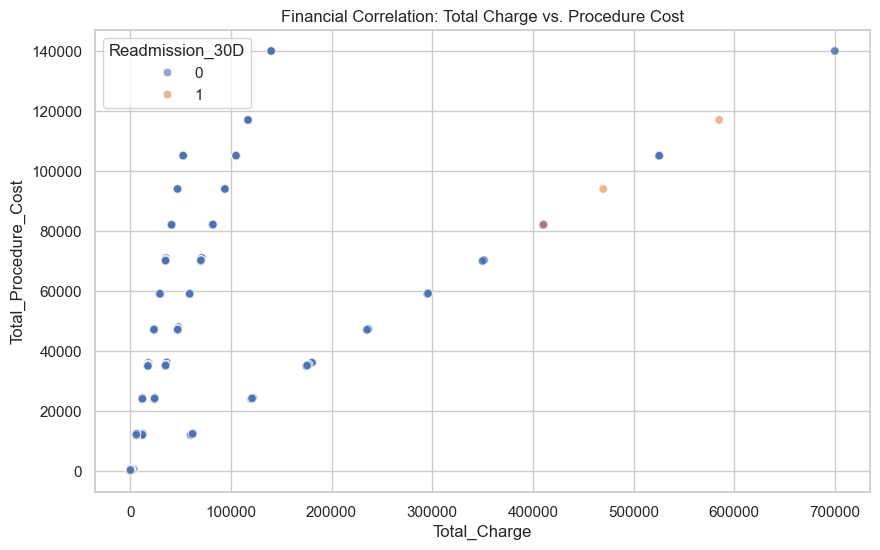

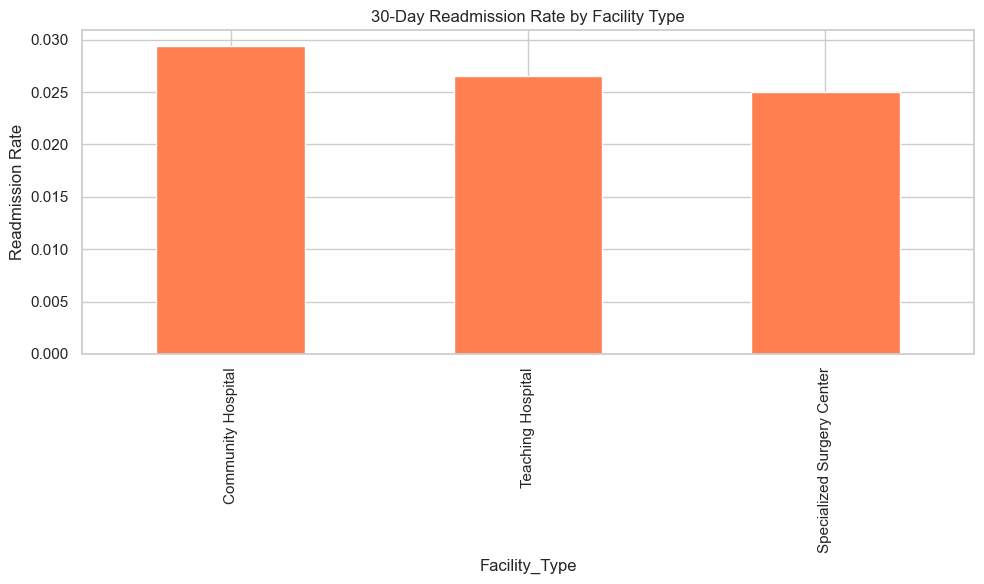

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Define the base path and load the newly updated Phase 3 table
path = r'C:\Users\atifn\Downloads\Patient Re-Adm Risk Data\\'
df = pd.read_excel(path + 'Master_EDA_Phase3.xlsx')

# Normalize column names
df.columns = df.columns.str.strip()

# Set visual style
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = [10, 6]

# Verified column names
age_col = 'Age_at_Encounter'
readmit_col = 'Readmission_30D'
acuity_col = 'Acuity_Score'
triage_col = 'Is_Triage_Only'

# 2. NEW: Bivariate Analysis - Readmission by Triage Status
plt.figure()
sns.barplot(x=triage_col, y=readmit_col, data=df, palette='Set2')
plt.title('Readmission Rate: Standard Care (0) vs. Triage-Only (1)')
plt.xlabel('Is Triage Only (Zero Charges/Procedures)')
plt.ylabel('Average Readmission Probability')
plt.savefig(path + 'EDA_Triage_Readmission_Rate.png')

# 3. Univariate Analysis: Age at Encounter Distribution
plt.figure()
sns.histplot(df[age_col], bins=20, kde=True, color='teal')
plt.title('Patient Age at Encounter Distribution')
plt.savefig(path + 'EDA_Age_Distribution.png')

# 4. Bivariate Analysis: Readmission Rate by Acuity Score
plt.figure()
sns.barplot(x=acuity_col, y=readmit_col, data=df, palette='viridis')
plt.title('30-Day Readmission Rate by Patient Acuity Score')
plt.savefig(path + 'EDA_Acuity_Readmission.png')

# 5. Financial Bivariate: Total Charge vs Total Procedure Cost
plt.figure()
sns.scatterplot(x='Total_Charge', y='Total_Procedure_Cost', hue=readmit_col, data=df, alpha=0.6)
plt.title('Financial Correlation: Total Charge vs. Procedure Cost')
plt.savefig(path + 'EDA_Charge_vs_Cost.png')

# 6. Categorical Analysis: Readmission by Facility Type
plt.figure()
facility_trends = df.groupby('Facility_Type')[readmit_col].mean().sort_values(ascending=False)
facility_trends.plot(kind='bar', color='coral')
plt.title('30-Day Readmission Rate by Facility Type')
plt.ylabel('Readmission Rate')
plt.tight_layout()
plt.savefig(path + 'EDA_Facility_Type_Trends.png')

print("Step 4 Analysis Complete.")
print(f"Verified Column Mapping: {age_col}, {readmit_col}, {acuity_col}, {triage_col}")
print("Five visualization files have been saved to the directory, including the new Triage analysis.")